In [1]:
# ==================================================
# IMPORT REQUIRED LIBRARIES
# ==================================================

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import random

import matplotlib.pyplot as plt

# Display PyTorch version
print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


In [2]:

# ==================================================
# AUTOMATIC SYNTHETIC DATASET GENERATION
# ==================================================

# Subjects
subjects = [
    ("i", "je"),
    ("you", "tu"),
    ("he", "il"),
    ("she", "elle"),
    ("we", "nous"),
    ("they", "ils")
]

# Verbs
verbs = [
    (("eat", "eats"), "mange"),
    (("drink", "drinks"), "boit"),
    (("read", "reads"), "lit"),
    (("write", "writes"), "ecrit"),
    (("play", "plays"), "joue"),
    (("watch", "watches"), "regarde"),
    (("open", "opens"), "ouvre"),
    (("close", "closes"), "ferme"),
    (("buy", "buys"), "achete"),
    (("love", "loves"), "aime")
]

# Objects
objects = [
    ("bread", "du pain"),
    ("water", "de l eau"),
    ("milk", "du lait"),
    ("tea", "du the"),
    ("coffee", "du cafe"),
    ("rice", "du riz"),
    ("a book", "un livre"),
    ("football", "au football"),
    ("music", "la musique"),
    ("the door", "la porte")
]

# Adjectives
adjectives = [
    ("happy", "heureux"),
    ("sad", "triste"),
    ("tired", "fatigue"),
    ("hungry", "affame"),
    ("strong", "fort"),
    ("smart", "intelligent"),
    ("kind", "gentil"),
    ("young", "jeune"),
    ("beautiful", "beau"),
    ("ready", "pret")
]

# Places
places = [
    ("school", "ecole"),
    ("park", "parc"),
    ("home", "maison"),
    ("city", "ville"),
    ("office", "bureau")
]

# ==================================================
# CREATE DATASET
# ==================================================

data = []

# ==========================================
# PATTERN 1
# Subject + be + adjective
# ==========================================

for eng_subj, fr_subj in subjects:

    for eng_adj, fr_adj in adjectives:

        if eng_subj in ["he", "she", "it"]:
            eng_sentence = f"{eng_subj} is {eng_adj}"
        elif eng_subj == "i":
            eng_sentence = f"{eng_subj} am {eng_adj}"
        else:
            eng_sentence = f"{eng_subj} are {eng_adj}"
        if fr_subj == "je":
            fr_sentence = f"{fr_subj} suis {fr_adj}"

        elif fr_subj == "tu":
            fr_sentence = f"{fr_subj} es {fr_adj}"

        elif fr_subj in ["il", "elle"]:
            fr_sentence = f"{fr_subj} est {fr_adj}"
        elif fr_subj == "nous":
            fr_sentence = f"{fr_subj} sommes {fr_adj}"
        else:
            fr_sentence = f"{fr_subj} sont {fr_adj}"

        data.append((eng_sentence, fr_sentence))

# ==========================================
# PATTERN 2
# Subject + verb + object
# ==========================================

for eng_subj, fr_subj in subjects:

    for verb_pair, fr_verb in verbs:

        singular_verb = verb_pair[1]
        plural_verb = verb_pair[0]

        for eng_obj, fr_obj in objects:

            if eng_subj in ["he", "she", "it"]:
                eng_sentence = f"{eng_subj} {singular_verb} {eng_obj}"
            else:
                eng_sentence = f"{eng_subj} {plural_verb} {eng_obj}"

            fr_sentence = f"{fr_subj} {fr_verb} {fr_obj}"

            data.append((eng_sentence, fr_sentence))

# ==========================================
# PATTERN 3
# Subject + verb + place
# ==========================================

for eng_subj, fr_subj in subjects:

    for verb_pair, fr_verb in verbs:

        singular_verb = verb_pair[1]
        plural_verb = verb_pair[0]

        for eng_place, fr_place in places:

            if eng_subj in ["he", "she", "it"]:
                eng_sentence = f"{eng_subj} {singular_verb} at the {eng_place}"
            else:
                eng_sentence = f"{eng_subj} {plural_verb} at the {eng_place}"

            fr_sentence = f"{fr_subj} {fr_verb} au {fr_place}"

            data.append((eng_sentence, fr_sentence))

# ==========================================
# PATTERN 4
# Questions
# ==========================================

questions = [
    ("how are you", "comment allez vous"),
    ("where are you", "ou etes vous"),
    ("what is this", "qu est ce"),
    ("who are they", "qui sont ils"),
    ("where is the book", "ou est le livre")
]

for q in questions:
    data.append(q)

# ==========================================
# PATTERN 5
# Greetings
# ==========================================

greetings = [
    ("good morning", "bonjour"),
    ("good night", "bonne nuit"),
    ("thank you", "merci"),
    ("see you later", "a plus tard"),
    ("you are welcome", "de rien")
]

for g in greetings:
    data.append(g)

# ==================================================
# PRINT DATASET INFORMATION
# ==================================================

print("Total sentence pairs:", len(data))

print("\nFirst 20 examples:\n")

for pair in data[:20]:
    print(pair)


Total sentence pairs: 970

First 20 examples:

('i am happy', 'je suis heureux')
('i am sad', 'je suis triste')
('i am tired', 'je suis fatigue')
('i am hungry', 'je suis affame')
('i am strong', 'je suis fort')
('i am smart', 'je suis intelligent')
('i am kind', 'je suis gentil')
('i am young', 'je suis jeune')
('i am beautiful', 'je suis beau')
('i am ready', 'je suis pret')
('you are happy', 'tu es heureux')
('you are sad', 'tu es triste')
('you are tired', 'tu es fatigue')
('you are hungry', 'tu es affame')
('you are strong', 'tu es fort')
('you are smart', 'tu es intelligent')
('you are kind', 'tu es gentil')
('you are young', 'tu es jeune')
('you are beautiful', 'tu es beau')
('you are ready', 'tu es pret')


In [3]:
# ==================================================
# BUILD VOCABULARY
# ==================================================

# Special tokens
special_tokens = ["<pad>", "<sos>", "<eos>"]

# Create dictionaries
eng_vocab = {}
fr_vocab = {}

# Add special tokens
for idx, token in enumerate(special_tokens):

    eng_vocab[token] = idx
    fr_vocab[token] = idx


# Function to build vocabulary
def build_vocab(sentences, vocab):

    index = len(vocab)

    for sentence in sentences:

        for word in sentence.split():

            if word not in vocab:

                vocab[word] = index
                index += 1


# Build vocabularies
build_vocab([pair[0] for pair in data], eng_vocab)
build_vocab([pair[1] for pair in data], fr_vocab)

print("English Vocabulary:\n")
print(eng_vocab)

print("\nFrench Vocabulary:\n")
print(fr_vocab)

English Vocabulary:

{'<pad>': 0, '<sos>': 1, '<eos>': 2, 'i': 3, 'am': 4, 'happy': 5, 'sad': 6, 'tired': 7, 'hungry': 8, 'strong': 9, 'smart': 10, 'kind': 11, 'young': 12, 'beautiful': 13, 'ready': 14, 'you': 15, 'are': 16, 'he': 17, 'is': 18, 'she': 19, 'we': 20, 'they': 21, 'eat': 22, 'bread': 23, 'water': 24, 'milk': 25, 'tea': 26, 'coffee': 27, 'rice': 28, 'a': 29, 'book': 30, 'football': 31, 'music': 32, 'the': 33, 'door': 34, 'drink': 35, 'read': 36, 'write': 37, 'play': 38, 'watch': 39, 'open': 40, 'close': 41, 'buy': 42, 'love': 43, 'eats': 44, 'drinks': 45, 'reads': 46, 'writes': 47, 'plays': 48, 'watches': 49, 'opens': 50, 'closes': 51, 'buys': 52, 'loves': 53, 'at': 54, 'school': 55, 'park': 56, 'home': 57, 'city': 58, 'office': 59, 'how': 60, 'where': 61, 'what': 62, 'this': 63, 'who': 64, 'good': 65, 'morning': 66, 'night': 67, 'thank': 68, 'see': 69, 'later': 70, 'welcome': 71}

French Vocabulary:

{'<pad>': 0, '<sos>': 1, '<eos>': 2, 'je': 3, 'suis': 4, 'heureux': 5, 't

In [4]:
# ==================================================
# TRANSLATION FUNCTION
# ==================================================

def translate_sentence(sentence):

    model.eval()

    # ==========================================
    # Tokenize input sentence
    # ==========================================

    tokens = tokenize(sentence, eng_vocab)

    # Handle unknown words
    if len(tokens) == 0:

        return "Unknown words in input sentence"

    # Convert to tensor
    src_tensor = torch.tensor(tokens).to(device)

    # ==========================================
    # Encoder
    # ==========================================

    with torch.no_grad():

        hidden, cell = model.encoder(src_tensor)

    # ==========================================
    # Start decoder with <sos>
    # ==========================================

    outputs = []

    x = torch.tensor(
        [fr_vocab["<sos>"]]
    ).to(device)

    # Maximum translation length
    for _ in range(20):

        with torch.no_grad():

            output, hidden, cell = model.decoder(
                x,
                hidden,
                cell
            )

        # Get predicted word
        best_guess = output.argmax(1).item()

        # Stop if <eos>
        if best_guess == fr_vocab["<eos>"]:
            break

        outputs.append(
            fr_idx_to_word[best_guess]
        )

        # Next input becomes prediction
        x = torch.tensor(
            [best_guess]
        ).to(device)

    return " ".join(outputs)

In [6]:
# ==================================================
# TOKENIZATION FUNCTION
# ==================================================

def tokenize(sentence, vocab):

    tokens = [vocab["<sos>"]]

    for word in sentence.split():

        # Check if word exists in vocabulary
        if word in vocab:

            tokens.append(vocab[word])

        else:

            print(f"Unknown word: {word}")

            return []

    tokens.append(vocab["<eos>"])

    return tokens

In [8]:
# ==================================================
# CONVERT DATA TO TENSORS
# ==================================================

pairs = []

for eng, fr in data:

    src_tokens = tokenize(eng, eng_vocab)
    trg_tokens = tokenize(fr, fr_vocab)

    src_tensor = torch.tensor(src_tokens)
    trg_tensor = torch.tensor(trg_tokens)

    pairs.append((src_tensor, trg_tensor))


print("Example source tensor:")
print(pairs[0][0])

print("\nExample target tensor:")
print(pairs[0][1])

Example source tensor:
tensor([1, 3, 4, 5, 2])

Example target tensor:
tensor([1, 3, 4, 5, 2])


In [9]:
# ==================================================
# DEVICE CONFIGURATION
# ==================================================

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [10]:
# ==================================================
# ENCODER
# ==================================================

class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers
        )

        self.dropout = nn.Dropout(dropout)


    def forward(self, x):

        # x shape:
        # [seq_len]

        # Add batch dimension
        x = x.unsqueeze(1)

        # Embedding
        embedded = self.dropout(
            self.embedding(x)
        )

        # LSTM
        outputs, (hidden, cell) = self.lstm(embedded)

        return hidden, cell

In [11]:
# ==================================================
# DECODER
# ==================================================

class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        self.output_dim = output_dim

        # Embedding layer
        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers
        )

        # Fully connected layer
        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)


    def forward(self, x, hidden, cell):

        # x shape:
        # scalar token

        # Add sequence and batch dimensions
        x = x.unsqueeze(0).unsqueeze(1)

        # Embedding
        embedded = self.dropout(
            self.embedding(x)
        )

        # Remove extra dimension created by embedding
        embedded = embedded.squeeze(2)

        # LSTM
        outputs, (hidden, cell) = self.lstm(
            embedded,
            (hidden, cell)
        )

        # Prediction
        prediction = self.fc(outputs.squeeze(0))

        return prediction, hidden, cell

In [12]:
# ==================================================
# SEQ2SEQ MODEL
# ==================================================

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device


    def forward(
        self,
        source,
        target,
        teacher_forcing_ratio=0.5
    ):

        # ==========================================
        # Target sentence length
        # ==========================================

        target_len = len(target)

        # Vocabulary size
        target_vocab_size = self.decoder.output_dim

        # Store decoder outputs
        outputs = torch.zeros(
            target_len,
            1,
            target_vocab_size
        ).to(self.device)

        # ==========================================
        # ENCODER
        # ==========================================

        hidden, cell = self.encoder(source)

        # First decoder input = <sos>
        x = target[0]

        # ==========================================
        # DECODER LOOP
        # ==========================================

        for t in range(1, target_len):

            output, hidden, cell = self.decoder(
                x,
                hidden,
                cell
            )

            outputs[t] = output

            # Get highest predicted token
            best_guess = output.argmax(1)

            # ======================================
            # TEACHER FORCING
            # ======================================

            teacher_force = random.random() < teacher_forcing_ratio

            # Use actual word OR predicted word
            x = target[t] if teacher_force else best_guess

        return outputs

In [13]:
# ==================================================
# HYPERPARAMETERS
# ==================================================

# Vocabulary sizes
input_dim = len(eng_vocab)
output_dim = len(fr_vocab)

# Embedding vector size
embedding_dim = 64

# LSTM hidden state size
hidden_dim = 128

# Number of LSTM layers
num_layers = 1

# Dropout rate
dropout = 0.2

print("Input Vocabulary Size :", input_dim)
print("Output Vocabulary Size:", output_dim)

Input Vocabulary Size : 72
Output Vocabulary Size: 72


In [14]:
# ==================================================
# INITIALIZE ENCODER & DECODER
# ==================================================

encoder = Encoder(
    input_dim,
    embedding_dim,
    hidden_dim,
    num_layers,
    dropout
)

decoder = Decoder(
    output_dim,
    embedding_dim,
    hidden_dim,
    num_layers,
    dropout
)

# Create Seq2Seq model
model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(72, 64)
    (lstm): LSTM(64, 128)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(72, 64)
    (lstm): LSTM(64, 128)
    (fc): Linear(in_features=128, out_features=72, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)


In [15]:
# ==================================================
# LOSS FUNCTION
# ==================================================

# Ignore padding token during loss calculation
pad_idx = fr_vocab["<pad>"]

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

print("Loss function initialized.")

Loss function initialized.


In [16]:
# ==================================================
# OPTIMIZER
# ==================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer initialized.")

Optimizer initialized.


In [17]:
# ==================================================
# TRAINING LOOP
# ==================================================

num_epochs = 10

# Store losses for graph
losses = []

model.train()

for epoch in range(num_epochs):

    epoch_loss = 0

    for src, trg in pairs:

        # Move tensors to device
        src = src.to(device)
        trg = trg.to(device)

        # ==========================================
        # RESET GRADIENTS
        # ==========================================

        optimizer.zero_grad()

        # ==========================================
        # FORWARD PASS
        # ==========================================

        output = model(src, trg)

        # ==========================================
        # RESHAPE OUTPUTS
        # Required for CrossEntropyLoss
        # ==========================================

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)

        trg = trg[1:].view(-1)

        # ==========================================
        # CALCULATE LOSS
        # ==========================================

        loss = criterion(output, trg)

        # ==========================================
        # BACKPROPAGATION
        # ==========================================

        loss.backward()

        # ==========================================
        # UPDATE WEIGHTS
        # ==========================================

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(pairs)

    losses.append(avg_loss)

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Loss: {avg_loss:.4f}")
        print()

In [18]:
# ==================================================
# TOKENIZATION FUNCTION
# ==================================================

def tokenize(sentence, vocab):

    tokens = [vocab["<sos>"]]

    for word in sentence.split():

        # Check if word exists in vocabulary
        if word in vocab:

            tokens.append(vocab[word])

        else:

            print(f"Unknown word: {word}")

            return []

    tokens.append(vocab["<eos>"])

    return tokens

In [19]:
# ==================================================
# REVERSE VOCABULARY
# integer -> word
# ==================================================

eng_idx_to_word = {

    idx: word for word, idx in eng_vocab.items()

}

fr_idx_to_word = {

    idx: word for word, idx in fr_vocab.items()

}

print(fr_idx_to_word)

{0: '<pad>', 1: '<sos>', 2: '<eos>', 3: 'je', 4: 'suis', 5: 'heureux', 6: 'triste', 7: 'fatigue', 8: 'affame', 9: 'fort', 10: 'intelligent', 11: 'gentil', 12: 'jeune', 13: 'beau', 14: 'pret', 15: 'tu', 16: 'es', 17: 'il', 18: 'est', 19: 'elle', 20: 'nous', 21: 'sommes', 22: 'ils', 23: 'sont', 24: 'mange', 25: 'du', 26: 'pain', 27: 'de', 28: 'l', 29: 'eau', 30: 'lait', 31: 'the', 32: 'cafe', 33: 'riz', 34: 'un', 35: 'livre', 36: 'au', 37: 'football', 38: 'la', 39: 'musique', 40: 'porte', 41: 'boit', 42: 'lit', 43: 'ecrit', 44: 'joue', 45: 'regarde', 46: 'ouvre', 47: 'ferme', 48: 'achete', 49: 'aime', 50: 'ecole', 51: 'parc', 52: 'maison', 53: 'ville', 54: 'bureau', 55: 'comment', 56: 'allez', 57: 'vous', 58: 'ou', 59: 'etes', 60: 'qu', 61: 'ce', 62: 'qui', 63: 'le', 64: 'bonjour', 65: 'bonne', 66: 'nuit', 67: 'merci', 68: 'a', 69: 'plus', 70: 'tard', 71: 'rien'}


In [20]:
# ==================================================
# TEST TRANSLATIONS
# ==================================================

test_sentences = [

    "i am happy",
    "he is tall",
    "good morning",
    "i love you"

]

for sentence in test_sentences:

    translation = translate_sentence(sentence)

    print(f"Input      : {sentence}")
    print(f"Translation: {translation}")
    print()

Input      : i am happy
Translation: je suis heureux

Unknown word: tall
Input      : he is tall
Translation: Unknown words in input sentence

Input      : good morning
Translation: bonjour

Input      : i love you
Translation: je aime au



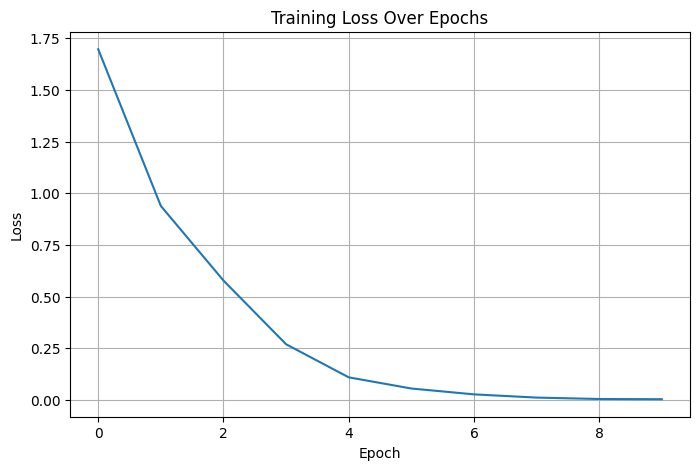

In [21]:
# ==================================================
# PLOT TRAINING LOSS
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss Over Epochs")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()